[[ 3.21165104e-06 -1.26941349e-05  9.59473328e-05 ...  2.26276352e-05
  -1.12058257e-04  1.23873586e-05]
 [-3.98566635e-05  1.30836480e-06 -3.20451079e-04 ... -4.55199244e-05
   1.60778443e-04  7.61190442e-07]
 [ 5.92711264e-05 -1.61870888e-05  1.64622691e-04 ...  5.84391108e-05
  -2.82218203e-04 -1.66558066e-05]
 ...
 [ 2.19506567e-04  2.81621989e-04  3.25309620e-04 ...  7.03864208e-07
  -7.50436487e-06  1.25813376e-05]
 [ 3.41601711e-04  2.31798881e-04  5.26630688e-04 ...  5.45191824e-05
   4.34891438e-05  5.15122464e-05]
 [-4.54156330e-04 -4.54308473e-04 -6.18025013e-04 ...  2.46461862e-05
   3.16452302e-05  3.44764433e-05]]


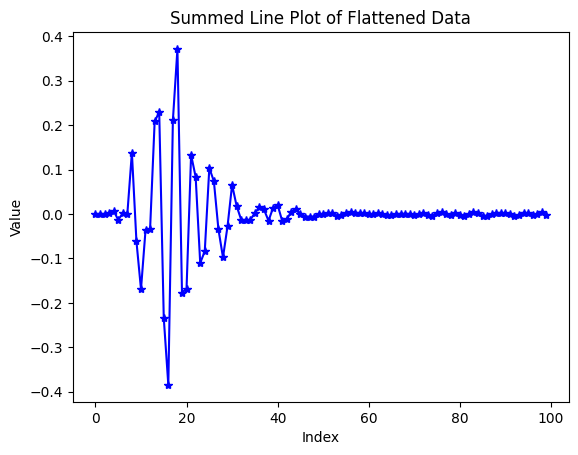

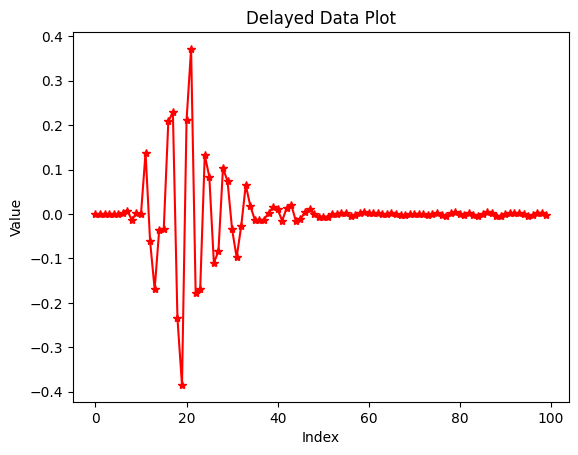

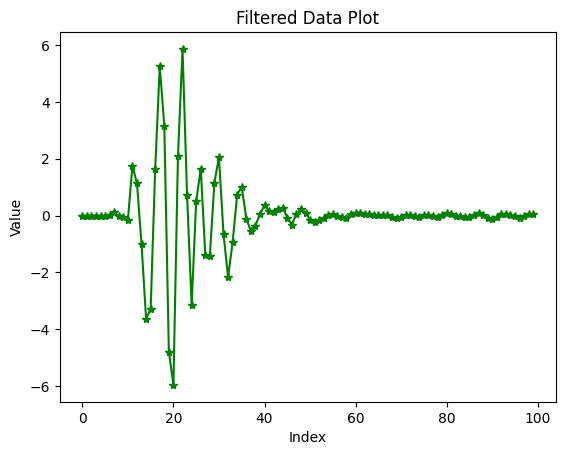

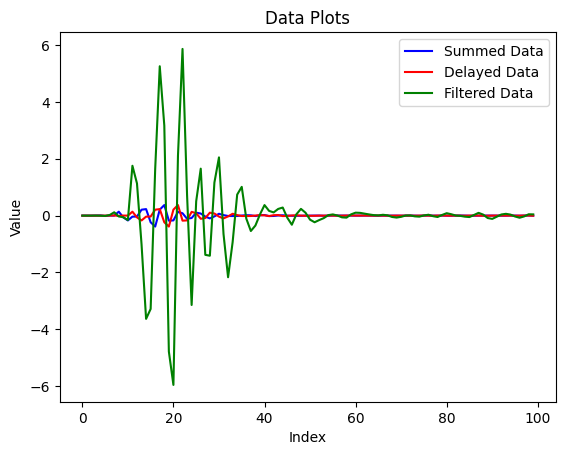

In [4]:
import scipy.io
import numpy as np
from matplotlib import pyplot as plt
from DelaySample import delay_sample  # Import the delay_sample function
from FilterSample import filter_sample  # Import the filter_sample function
from PemAFCinit import PemAFCinit  # Import the PemAFCinit function

# Load .mat file
mat_data = scipy.io.loadmat('D:\\De_tai_sinh_vien\\code_python\\sound_test\\mFBPathIRs16kHz_PhoneNear.mat')

# Access the actual variable inside the .mat file
data = mat_data['mFBPathIRs16kHz_PhoneNear']  # Shape: (100, 10, 3)

# Convert the data to a 2D matrix for display (flatten the 3D data into 2D)
flattened_data = data.reshape(data.shape[0], -1)  # Shape will become (100, 30)

# Print the 2D matrix
print(flattened_data)

# Sum the columns to get a single line
summed_data = np.sum(flattened_data, axis=1)

# Plot the summed data as a single line
plt.figure()
plt.plot(summed_data, color='blue', marker='*', linestyle='-')
plt.title('Summed Line Plot of Flattened Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\summed_plot.png')  # Save the plot to a file

# Initialize delay parameters
delay = 3  # Set delay to 3
delayline_in = np.zeros((delay + 1, flattened_data.shape[1]))  # Initialize delay line

# Apply delay_sample function to each sample
delayed_data = []
for i in range(flattened_data.shape[0]):
    output, delayline_in = delay_sample(flattened_data[i, :], delay, delayline_in)
    delayed_data.append(output)

delayed_data = np.array(delayed_data)
summed_delayed_data = np.sum(delayed_data, axis=1)

# Plot the delayed data
plt.figure()
plt.plot(summed_delayed_data, color='red', marker='*', linestyle='-')
plt.title('Delayed Data Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\delayed_plot.png')  # Save the plot to a file

# Initialize filter parameters
filterlength = 3
nr_filter = delayed_data.shape[1]
w = np.random.rand(filterlength, nr_filter)
filter_delayline_in = np.zeros((filterlength, nr_filter))  # Corrected initialization

# Apply filter_sample function to each sample
filtered_data = []
for i in range(delayed_data.shape[0]):
    output, filter_delayline_in = filter_sample(delayed_data[i, :].reshape(1, -1), w, filter_delayline_in)
    filtered_data.append(output)

filtered_data = np.array(filtered_data).reshape(delayed_data.shape[0], -1)
summed_filtered_data = np.sum(filtered_data, axis=1)

# Plot the filtered data as a single line
plt.figure()
plt.plot(summed_filtered_data, color='green', marker='*', linestyle='-')
plt.title('Filtered Data Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\filtered_plot.png')  # Save the plot to a file



# Plot all data in one figure
plt.figure()
plt.plot(summed_data, color='blue', label='Summed Data')
plt.plot(summed_delayed_data, color='red', label='Delayed Data')
plt.plot(summed_filtered_data, color='green', label='Filtered Data')
plt.title('Data Plots')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\combined_plot.png')
# Save the plot to a file

# Show the plots (this will not work in WSL, but you can view the saved files)
plt.show()

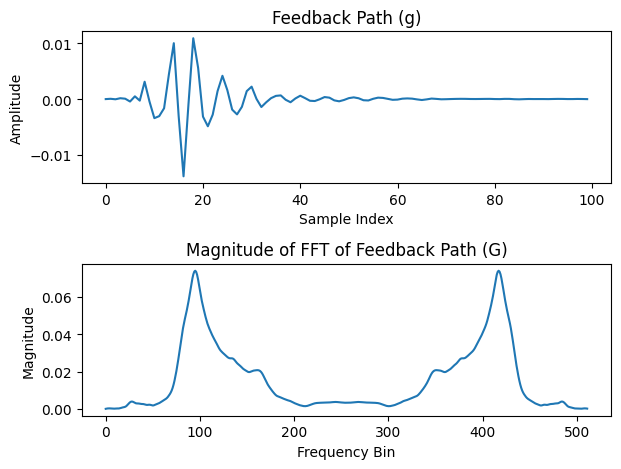

In [5]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import lfilter, firwin
from PemAFCinit import PemAFCinit

# Load the .mat file
mat_data = scipy.io.loadmat('D:\\De_tai_sinh_vien\\code_python\\sound_test\\mFBPathIRs16kHz_FF.mat')

# Access the actual variable inside the .mat file
E = mat_data['mFBPathIRs16kHz_FF'][:, 3, 1, 1]

# Remove the mean value
g = E - np.mean(E)

# Length of the feedback path
Lg = len(g)

# Number of frequency bins for FFT
Nfreq = 512

# Perform FFT
G = np.fft.fft(g, Nfreq)

# Initialize the time-delay vector
TDLy = np.zeros((Lg, 1))

# Settings for the desired signal
in_sig = 3  # Change this value to 0, 1, 2, or 3 based on your desired input signal
N = 16000  # Example value for N

if in_sig == 0:
    # 0) incoming signal is a white noise
    Var_noise = 0.001
    input_signal = np.sqrt(Var_noise) * np.random.randn(N, 1)
elif in_sig == 1:
    # 1) incoming signal is a synthesized speech
    Var = 1
    h_den = [1, -2 * 0.96 * np.cos(3000 * 2 * np.pi / 15750), 0.96 ** 2]
    v = np.sqrt(Var) * np.random.randn(N, 1)
    input_signal = lfilter([1], h_den, v)
elif in_sig == 2:
    # 2) incoming signal is a real speech segment from NOIZEUS
    mat_data = scipy.io.loadmat('D:\\De_tai_sinh_vien\\code_python\\sound_test\\HeadMid2_Speech_Vol095_0dgs_m1.mat')
    input_signal = mat_data['HeadMid2_Speech_Vol095_0dgs_m1'][:N, 0]
else:
    # 3) incoming signal is a music
    mat_data = scipy.io.loadmat('D:\\De_tai_sinh_vien\\code_python\\sound_test\\HeadMid2_Music_Vol095_0dgs_m1.mat')
    input1 = mat_data['HeadMid2_Music_Vol095_0dgs_m1']
    input_signal = input1[16000:N + 16000, 0]

# Normalize the input signal
input_signal = input_signal / np.max(np.abs(input_signal))

# Example usage of u and u_
u_ = input_signal  # Assuming u_ is the input signal
u = np.zeros(N)  # Initialize u with zeros

for n in range(N):
    u[n] = u_[n]  # Extract a single element from the array


# Plot the feedback path
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(g)
plt.title('Feedback Path (g)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

# Plot the magnitude of the FFT
plt.subplot(2, 1, 2)
plt.plot(np.abs(G))
plt.title('Magnitude of FFT of Feedback Path (G)')
plt.xlabel('Frequency Bin')
plt.ylabel('Magnitude')
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\feedback_path.png')
# Show the plots
plt.tight_layout()
plt.show()


In [4]:
import numpy as np
from DelaySample import delay_sample
from FilterSample import filter_sample
from PemAFCinit import PemAFCinit

class ARModel:
    def __init__(self, N_ar, framelength_ar):
        self.N = N_ar
        self.w = np.array([1] + [0] * (N_ar - 1))  # Coefficients of previous AR-model
        self.framelength = framelength_ar  # Frame length on which AR model is estimated
        self.frameindex = 0  # Frame index
        self.TDLMicdelay = np.zeros((framelength_ar + 1, 1))  # Time-delay line of microphone samples
        self.TDLLsdelay = np.zeros((framelength_ar + 1, 1))  # Time-delay line of loudspeaker samples
        self.TDLMicwh = np.zeros(N_ar)  # Time-delay line of pre-whitened microphone signal
        self.TDLLswh = np.zeros(N_ar)  # Time-delay line of pre-whitened loudspeaker signal
        self.frame = np.zeros(framelength_ar)  # Frame of error signals on which AR model is computed

# Khởi tạo ARModel với framelength_ar = 3
AR = ARModel(N_ar=4, framelength_ar=3)

# Dữ liệu mẫu
Mic = np.array([1])  # Mảng 1D, cần chuyển thành mảng 2D trước khi truyền vào hàm delay_sample
Ls = np.array([2])   # Mảng 1D, cần chuyển thành mảng 2D trước khi truyền vào hàm delay_sample

# Sử dụng hàm delay_sample để cập nhật delay line và lấy dữ liệu đầu ra
Micdelay, AR.TDLMicdelay = delay_sample(Mic, AR.framelength, AR.TDLMicdelay)
Lsdelay, AR.TDLLsdelay = delay_sample(Ls, AR.framelength, AR.TDLLsdelay)

print("Micdelay:", Micdelay)
print("AR.TDLMicdelay:", AR.TDLMicdelay)

print("Lsdelay:", Lsdelay)
print("AR.TDLLsdelay:", AR.TDLLsdelay)

Micdelay: [0.]
AR.TDLMicdelay: [[1.]
 [0.]
 [0.]
 [0.]]
Lsdelay: [0.]
AR.TDLLsdelay: [[2.]
 [0.]
 [0.]
 [0.]]


dict_keys(['__header__', '__version__', '__globals__', 'ans', 'N', 'tip_zg', 'coeff', 'fid', 'x', 'A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4', 'B4', 'A5', 'B5', 'A6', 'B6', 'A7', 'B7', 'B', 'h1', 'd', 'miu', 'a', 'ord', 'p', 'dlt', 'x2'])


C:\Users\thang\AppData\Local\Temp\ipykernel_4664\3476960977.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  miu = float(mat_data['miu'])  # step size
C:\Users\thang\AppData\Local\Temp\ipykernel_4664\3476960977.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ord = int(mat_data['ord'])  # length of the adaptive filter
C:\Users\thang\AppData\Local\Temp\ipykernel_4664\3476960977.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = int(mat_data['p'])  # pr

Normalized misalignment in dB: [[33.6236062 ]
 [31.10485105]
 [31.2190459 ]
 ...
 [29.23193047]
 [29.23198649]
 [29.23197697]]


Text(0, 0.5, 'Magnitude (dB)')

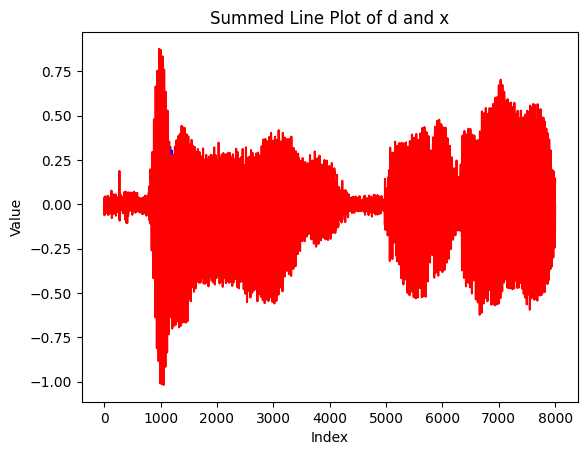

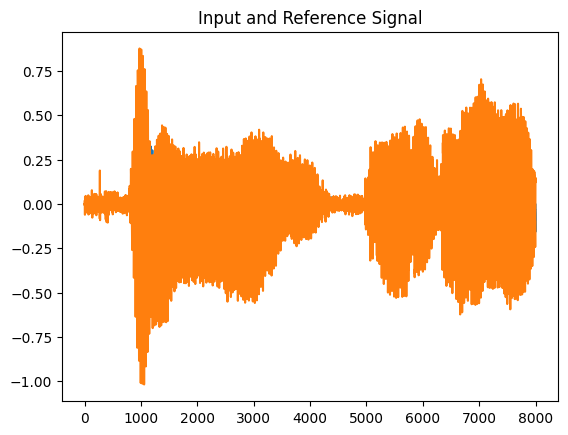

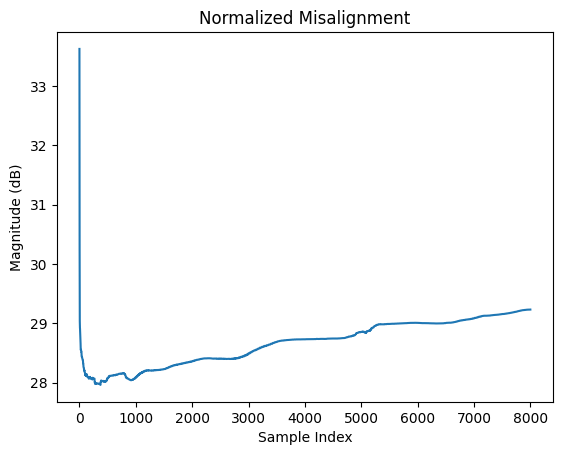

In [7]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# Load the .mat file
mat_data = scipy.io.loadmat('D:\\De_tai_sinh_vien\\code_python\\sound_test\\ex_eusipco_2010.mat')

summed_data_d = np.sum(mat_data['d'], axis=1)
summed_data_x = np.sum(mat_data['x'], axis=1)

plt.figure()
plt.plot(summed_data_d, color='blue', linestyle='-')
plt.plot(summed_data_x, color='red', linestyle='-')
plt.title('Summed Line Plot of d and x')
plt.xlabel('Index')
plt.ylabel('Value')
plt.savefig('D:\\De_tai_sinh_vien\\code_python\\plot\\summed_plot_d_x.png')



print(mat_data.keys())

d = mat_data['d'].flatten()  # reference signal
x = mat_data['x'].flatten()  # far-end signal
miu = float(mat_data['miu'])  # step size
ord = int(mat_data['ord'])  # length of the adaptive filter
p = int(mat_data['p'])  # projection order
dlt = float(mat_data['dlt'])  # regularization constant
a = float(mat_data['a'])  # IPNLMS parameter
h1 = mat_data['h1'].flatten()  # true impulse response of the echo path


N = len(x)  # Length of the input signal
w = np.zeros((ord, 1))  # Initialize the filter coefficients
x1 = np.zeros((ord, 1))  # Initialize the input signal vector
D = np.zeros((p, 1))  # Initialize the desired signal vector
X = np.zeros((ord, p))
P = np.zeros((ord, p))
m = np.zeros((N, 1))
e = np.zeros((N, 1))
S0 = dlt * np.eye(p)
S = np.zeros((p, p))

for n in range(N):
    x1 = np.vstack([x[n], x1[:ord-1]])  # Update x1 with the new sample
    ep = d[n] - np.dot(x1.T, w)  # Calculate the prediction error
    w = w + miu / (np.linalg.norm(x1)**2 + 1e-8) * x1 * ep  # Update the filter coefficients
    m[n] = 20 * np.log10(np.linalg.norm(w - h1) / np.linalg.norm(h1))  # Calculate the normalized misalignment

# # Hiển thị kết quả
print(f'Normalized misalignment in dB: {m}')


plt.figure()
plt.plot(m)
plt.title('Normalized Misalignment')
plt.xlabel('Sample Index')
plt.ylabel('Magnitude (dB)')
